In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn           as sns
import pickle, os, json

from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

PALETTE = ["#1a6b4a","#e63946","#457b9d","#f4a261","#2a9d8f","#8338ec","#3a86ff"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful.")

All imports successful.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving central_uganda_youth_ART..csv to central_uganda_youth_ART..csv


In [3]:
# Run this first cell before anything else
!pip install scikit-learn --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('central_uganda_youth_ART..csv')
# ============================================================
# STEP 1: REMOVE ALL LEAKAGE COLUMNS
# These all encode outcome information directly or post-outcome
# ============================================================
leakage_columns = [
    # Original leakage columns (viral load measurements = the outcome itself)
    'viral_load_last',
    'latest_VL_last_visit',
    'baseline_VL_visit1',
    'vl_trend_direction',
    'suppression_improving',

    # Additional leakage columns identified from correlation analysis
    'iac_sessions_received',    # IAC triggered BY viral non-suppression
    'mean_adherence_visits',    # Aggregates post-baseline visit data
]

df_clean = df.drop(columns=leakage_columns)
print(f"Columns after leakage removal: {df_clean.shape[1]}")

# ============================================================
# STEP 2: SEPARATE TARGET AND FEATURES
# Always do this before any splitting or scaling
# ============================================================
X = df_clean.drop(columns=['viral_suppressed', 'patient_id'])
y = df_clean['viral_suppressed']

# ============================================================
# STEP 3: SPLIT FIRST — before any scaling or imputation
# This is critical. Fitting the scaler on full data = leakage
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # preserves 56/44 class ratio
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train suppression rate: {y_train.mean():.3f}")
print(f"Test suppression rate:  {y_test.mean():.3f}")

# ============================================================
# STEP 4: ENCODE CATEGORICALS
# Fit encoders only on training data
# ============================================================
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

# One-hot encode
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)
X_test_encoded  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=False)

# Align columns — test may be missing some dummy columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print(f"Feature dimensions after encoding: {X_train_encoded.shape[1]}")

# ============================================================
# STEP 5: IMPUTE MISSING VALUES
# Fit imputer only on training data
# ============================================================
# MICE for depression_category (already one-hot encoded by now)
# Use IterativeImputer (MICE equivalent) for all remaining missing values
imputer = IterativeImputer(random_state=42, max_iter=10)
X_train_imputed = imputer.fit_transform(X_train_encoded)
X_test_imputed  = imputer.transform(X_test_encoded)  # transform only

# ============================================================
# STEP 6: SCALE — fit only on training data
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)  # transform only, never fit

print(f"\nFinal training set shape: {X_train_scaled.shape}")
print(f"Final test set shape:     {X_test_scaled.shape}")
print("\nPreprocessing complete. No leakage.")

Columns after leakage removal: 46
Train size: (16712, 44), Test size: (4178, 44)
Train suppression rate: 0.439
Test suppression rate:  0.439

Categorical columns: ['sex', 'district', 'schooling_status', 'boarding_school', 'employment_status', 'ART_regimen', 'drug_resistance_tested', 'drug_resistance_detected', 'food_insecurity', 'caregiver_support', 'HIV_status_disclosed', 'depression_category', 'hazardous_drinking', 'treatment_interruption', 'enrolled_in_OTZ', 'enrolled_in_DSD', 'has_YAPS_support', 'iac_completed', 'ever_switched_regimen', 'dtg_transition_made']
Feature dimensions after encoding: 77

Final training set shape: (16712, 77)
Final test set shape:     (4178, 77)

Preprocessing complete. No leakage.


In [5]:
#  Load
df = pd.read_csv("central_uganda_youth_ART..csv")
print(f"Raw shape: {df.shape}")

# Binary yes/no columns
binary_yes_no = [
    'food_insecurity','treatment_interruption','hazardous_drinking',
    'enrolled_in_OTZ','enrolled_in_DSD','has_YAPS_support',
    'HIV_status_disclosed','boarding_school','ever_switched_regimen',
    'dtg_transition_made','iac_completed','drug_resistance_tested',
    'suppression_improving'
]
for c in binary_yes_no:
    df[c] = (df[c] == 'Yes').astype(int)

# Other binary
df['sex']                      = (df['sex'] == 'Female').astype(int)
df['drug_resistance_detected']  = df['drug_resistance_detected'].map(
    {'No': 0, 'Not Tested': 0, 'Yes': 1})

#  Ordinal
df['caregiver_support'] = df['caregiver_support'].map({'Low': 0, 'Medium': 1, 'High': 2})

# One-hot encode
df = pd.get_dummies(df, columns=[
    'district','schooling_status','ART_regimen',
    'employment_status','vl_trend_direction','depression_category'
], drop_first=True)

# ── Drop ID + ALL leakage columns ────────────────────────────────────────
# Original drops
DROP_COLS = [
    'patient_id',
    'viral_load_last',
    'latest_VL_last_visit',
    'baseline_VL_visit1',
    # ↓ LEAKAGE FIXES: these columns encode outcome-time information
    'suppression_improving',         # directly encodes the outcome
    'iac_sessions_received',          # given because of unsuppression
    'iac_completed',                  # same — outcome-time variable
    'mean_adherence_visits',          # measured at outcome time
    'adherence_self_report',          # self-reported at outcome time
    'appointment_adherence_pct',      # outcome-time measurement
    'appointments_kept',              # outcome-time measurement
    'missed_appointments_last12m',    # outcome-time measurement
    'mean_missed_doses_30d',          # outcome-time measurement
]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]  # safe drop
df = df.drop(columns=DROP_COLS).dropna()

TARGET       = 'viral_suppressed'
TREATMENTS   = ['enrolled_in_OTZ', 'enrolled_in_DSD', 'has_YAPS_support']
FEATURE_COLS = [c for c in df.columns if c != TARGET]

X = df[FEATURE_COLS].values.astype(float)
y = df[TARGET].values.astype(int)

print(f"Clean shape  : {df.shape}")
print(f"Features     : {len(FEATURE_COLS)}")
print(f"Suppressed   : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Unsuppressed : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")


Raw shape: (20890, 53)
Clean shape  : (20890, 52)
Features     : 51
Suppressed   : 9178 (43.9%)
Unsuppressed : 11712 (56.1%)


In [6]:
#  Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Keep a DataFrame version of test set (needed for G-computation counterfactuals)
X_test_df   = pd.DataFrame(X_test, columns=FEATURE_COLS)
X_train_df  = pd.DataFrame(X_train, columns=FEATURE_COLS)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")


Train: (16712, 51)  |  Test: (4178, 51)


In [7]:
#  G-Net Step 1: Propensity Models
# These model P(A=1 | L) — the probability of receiving each intervention
# given baseline covariates. Used to characterise selection bias.

BASE_COVS = [
    'age','sex','years_on_ART','baseline_CD4','BMI','distance_to_clinic_km',
    'stigma_score','social_support_score','PHQ9_score','alcohol_AUDITC_score',
    'caregiver_support','food_insecurity','treatment_interruption'
]

base_idx   = [FEATURE_COLS.index(c) for c in BASE_COVS if c in FEATURE_COLS]
X_base_tr  = X_train_s[:, base_idx]
X_base_te  = X_test_s[:,  base_idx]

prop_models   = {}
prop_auc      = {}
TREAT_LABELS  = {'enrolled_in_OTZ':'OTZ','enrolled_in_DSD':'DSD','has_YAPS_support':'YAPS'}

for t in TREATMENTS:
    t_idx   = FEATURE_COLS.index(t)
    A_train = X_train[:, t_idx].astype(int)
    A_test  = X_test[:,  t_idx].astype(int)

    m = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1
    )
    m.fit(X_base_tr, A_train)
    auc = roc_auc_score(A_test, m.predict_proba(X_base_te)[:, 1])
    prop_models[t] = m
    prop_auc[t]    = auc
    print(f"  Propensity [{TREAT_LABELS[t]}]  AUC = {auc:.4f}")

print("\nPropensity models fitted.")


  Propensity [OTZ]  AUC = 0.6226
  Propensity [DSD]  AUC = 0.5128
  Propensity [YAPS]  AUC = 0.4914

Propensity models fitted.


In [8]:
# ── G-Net Step 2: Outcome Model ──────────────────────────────────────────
# Predicts P(Y=1 | A, L) — suppression probability given all features

gnet_outcome = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    learning_rate="adaptive",
    learning_rate_init=0.0005,
    tol=1e-5,
)
gnet_outcome.fit(X_train_s, y_train)

gnet_probs  = gnet_outcome.predict_proba(X_test_s)[:, 1]
gnet_preds  = (gnet_probs >= 0.5).astype(int)
gnet_auc    = roc_auc_score(y_test, gnet_probs)

# ── Training diagnostics ─────────────────────────────────────────────────
print(f"Epochs trained     : {len(gnet_outcome.loss_curve_)}")
print(f"Best epoch         : {np.argmax(gnet_outcome.validation_scores_) + 1}")
print(f"Best val score     : {max(gnet_outcome.validation_scores_):.4f}")
print(f"Final training loss: {gnet_outcome.loss_curve_[-1]:.4f}")
print()
print(f"G-Net Outcome Model — ROC-AUC: {gnet_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gnet_preds, target_names=["Not Suppressed", "Suppressed"]))


Epochs trained     : 62
Best epoch         : 31
Best val score     : 0.8584
Final training loss: 0.2688

G-Net Outcome Model — ROC-AUC: 0.9124

Classification Report:
                precision    recall  f1-score   support

Not Suppressed       0.88      0.85      0.86      2342
    Suppressed       0.82      0.85      0.83      1836

      accuracy                           0.85      4178
     macro avg       0.85      0.85      0.85      4178
  weighted avg       0.85      0.85      0.85      4178



In [9]:
# ── G-Net Step 3: G-Computation Counterfactuals ─────────────────────────
# For each treatment: set A=1 for ALL patients, then A=0 for ALL patients
# ATE = E[Y(1)] - E[Y(0)]

gnet_ate     = {}
gnet_cate_df = pd.DataFrame({'y_true': y_test})

for t in TREATMENTS:
    label  = TREAT_LABELS[t]
    t_idx  = FEATURE_COLS.index(t)

    # Counterfactual: everyone treated
    X_cf1      = X_test_df.copy()
    X_cf1[t]   = 1
    X_cf1_s    = scaler.transform(X_cf1.values)   # ← FIXED: use .values (all 60 features)
    p1         = gnet_outcome.predict_proba(X_cf1_s)[:, 1]

    # Counterfactual: no one treated
    X_cf0      = X_test_df.copy()
    X_cf0[t]   = 0
    X_cf0_s    = scaler.transform(X_cf0.values)   # ← FIXED: use .values (all 60 features)
    p0         = gnet_outcome.predict_proba(X_cf0_s)[:, 1]

    ate  = p1.mean() - p0.mean()
    cate = p1 - p0

    gnet_ate[label]               = {'E_Y1': p1.mean(), 'E_Y0': p0.mean(), 'ATE': ate}
    gnet_cate_df[f'CATE_{label}'] = cate

    print(f"  [{label}]  E[Y|A=1]={p1.mean():.4f}  E[Y|A=0]={p0.mean():.4f}  ATE={ate:+.4f}")

print("\nG-computation complete.")

  [OTZ]  E[Y|A=1]=0.4708  E[Y|A=0]=0.4393  ATE=+0.0315
  [DSD]  E[Y|A=1]=0.4647  E[Y|A=0]=0.4396  ATE=+0.0251
  [YAPS]  E[Y|A=1]=0.4505  E[Y|A=0]=0.4491  ATE=+0.0014

G-computation complete.


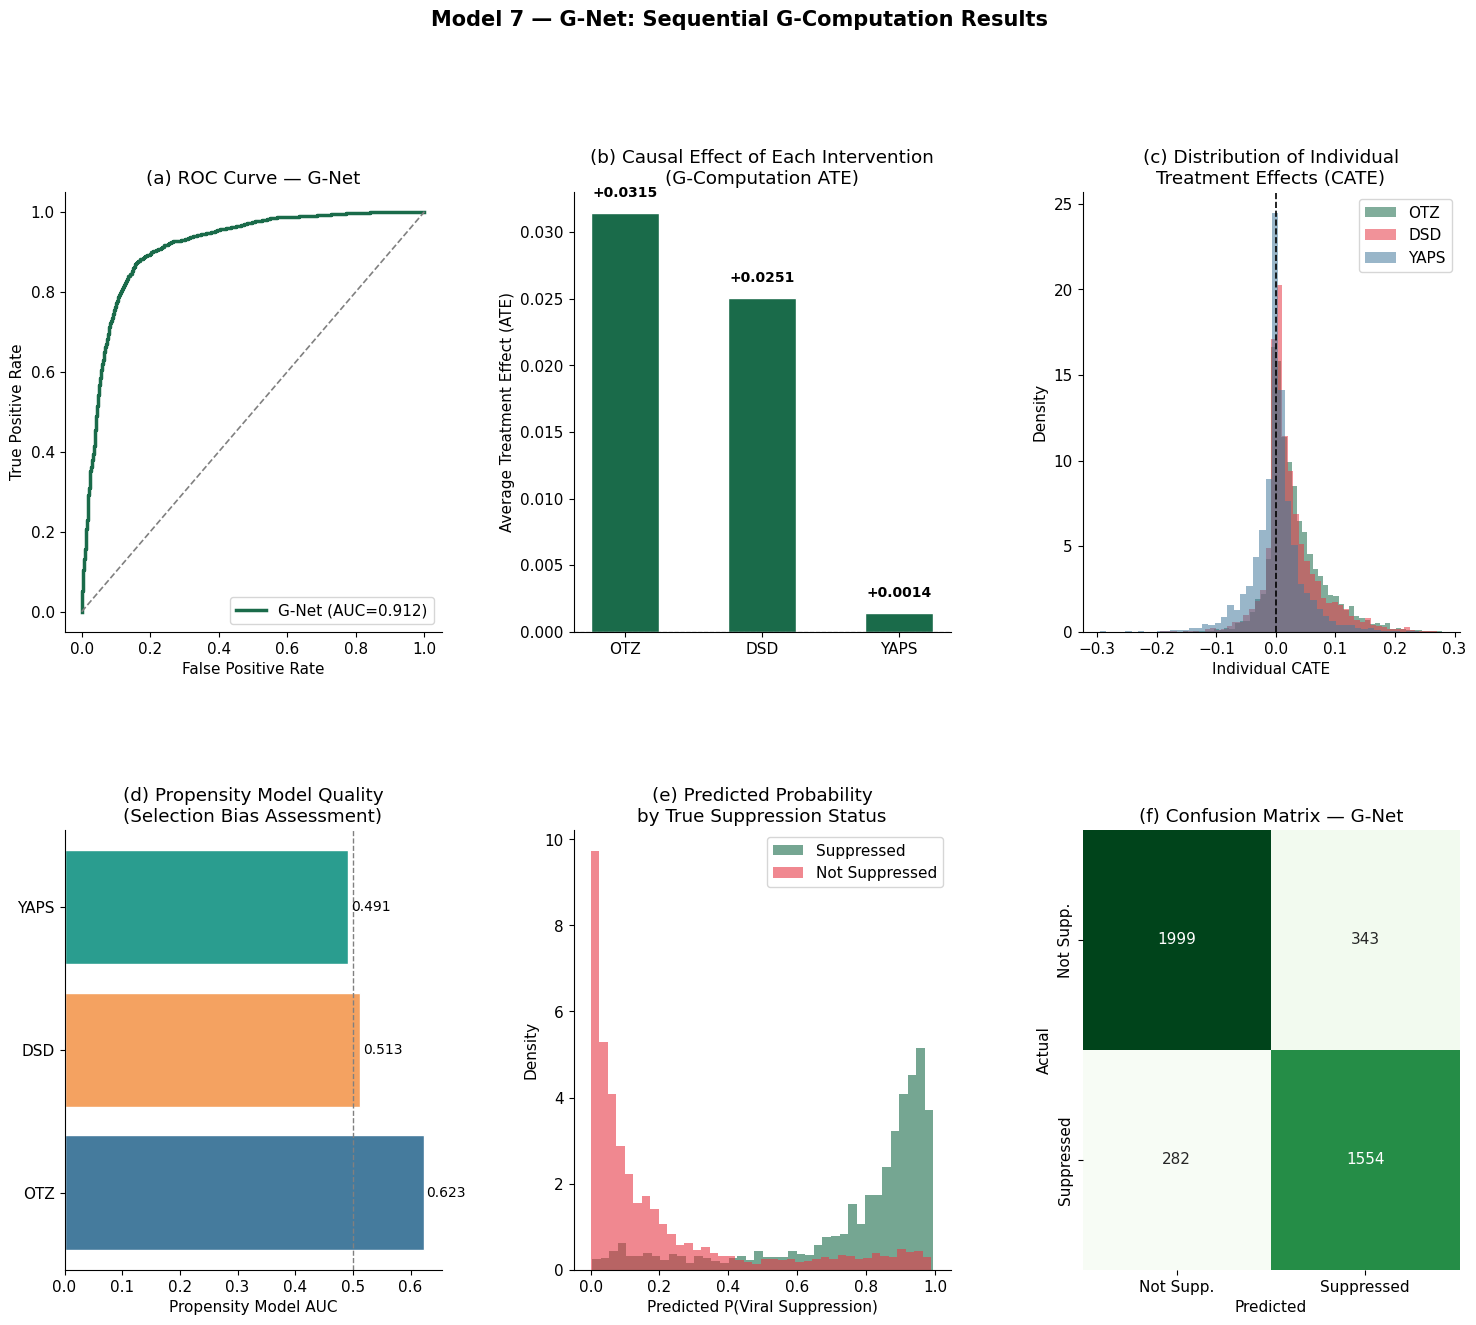


G-Net Summary: AUC=0.9124 | Best ATE: OTZ=+0.0315


In [10]:
# ── G-Net Visualisation ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) ROC Curve ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, gnet_probs)
ax1.plot(fpr, tpr, color=PALETTE[0], lw=2.5, label=f"G-Net (AUC={gnet_auc:.3f})")
ax1.plot([0,1],[0,1],'--', color='grey', lw=1.2)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("(a) ROC Curve — G-Net"); ax1.legend()

# ── (b) ATE bar chart ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
labels = list(gnet_ate.keys())
ates   = [gnet_ate[l]['ATE'] for l in labels]
colors = [PALETTE[0] if a > 0 else PALETTE[1] for a in ates]
bars   = ax2.bar(labels, ates, color=colors, edgecolor='white', width=0.5)
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_ylabel("Average Treatment Effect (ATE)")
ax2.set_title("(b) Causal Effect of Each Intervention\n(G-Computation ATE)")
for bar, ate in zip(bars, ates):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f"{ate:+.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── (c) CATE distributions ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for i, t in enumerate(['OTZ','DSD','YAPS']):
    ax3.hist(gnet_cate_df[f'CATE_{t}'], bins=50, alpha=0.55,
             color=PALETTE[i], label=t, density=True)
ax3.axvline(0, color='black', lw=1.2, ls='--')
ax3.set_xlabel("Individual CATE"); ax3.set_ylabel("Density")
ax3.set_title("(c) Distribution of Individual\nTreatment Effects (CATE)")
ax3.legend()

# ── (d) Propensity AUC bar ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
p_labels = [TREAT_LABELS[t] for t in TREATMENTS]
p_aucs   = [prop_auc[t] for t in TREATMENTS]
ax4.barh(p_labels, p_aucs, color=PALETTE[2:5], edgecolor='white')
ax4.axvline(0.5, color='grey', ls='--', lw=1)
ax4.set_xlabel("Propensity Model AUC")
ax4.set_title("(d) Propensity Model Quality\n(Selection Bias Assessment)")
for i, (v, l) in enumerate(zip(p_aucs, p_labels)):
    ax4.text(v+0.005, i, f"{v:.3f}", va='center', fontsize=10)

# ── (e) Predicted probability by suppression status ──────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for sup, col, lbl in zip([1,0], [PALETTE[0], PALETTE[1]],
                          ['Suppressed','Not Suppressed']):
    ax5.hist(gnet_probs[y_test==sup], bins=40, alpha=0.6,
             color=col, label=lbl, density=True)
ax5.set_xlabel("Predicted P(Viral Suppression)")
ax5.set_ylabel("Density")
ax5.set_title("(e) Predicted Probability\nby True Suppression Status")
ax5.legend()

# ── (f) Confusion matrix ──────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cm  = confusion_matrix(y_test, gnet_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Supp.','Suppressed'],
            yticklabels=['Not Supp.','Suppressed'], ax=ax6, cbar=False)
ax6.set_xlabel("Predicted"); ax6.set_ylabel("Actual")
ax6.set_title("(f) Confusion Matrix — G-Net")

fig.suptitle("Model 7 — G-Net: Sequential G-Computation Results",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"\nG-Net Summary: AUC={gnet_auc:.4f} | Best ATE: OTZ={gnet_ate['OTZ']['ATE']:+.4f}")


In [11]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

# Accuracy metrics
accuracy          = accuracy_score(y_test, gnet_preds)
balanced_accuracy = balanced_accuracy_score(y_test, gnet_preds)
auc               = roc_auc_score(y_test, gnet_probs)

print("=" * 40)
print("       G-Net Model Accuracy Summary")
print("=" * 40)
print(f"  Accuracy          : {accuracy*100:.2f}%")
print(f"  Balanced Accuracy : {balanced_accuracy*100:.2f}%")
print(f"  ROC-AUC           : {auc:.4f}")
print("=" * 40)

       G-Net Model Accuracy Summary
  Accuracy          : 85.04%
  Balanced Accuracy : 85.00%
  ROC-AUC           : 0.9124


In [12]:
#STRUCTURAL PRUNING
# ══════════════════════════════════════════════════════════
# STEP 1: Train full model and define full_params
print("Training full baseline model (64→32)...")

full_model = MLPClassifier(
    hidden_layer_sizes  = (64, 32),
    activation          = 'relu',
    max_iter            = 500,
    random_state        = RANDOM_STATE,
    early_stopping      = True,
    validation_fraction = 0.15,
    n_iter_no_change    = 30,
    learning_rate       = 'adaptive',
    learning_rate_init  = 0.0005,
    tol                 = 1e-5,
)
full_model.fit(X_train_s, y_train)

full_probs  = full_model.predict_proba(X_test_s)[:, 1]
full_preds  = (full_probs >= 0.5).astype(int)
full_auc    = roc_auc_score(y_test, full_probs)
full_acc    = accuracy_score(y_test, full_preds)
full_f1     = f1_score(y_test, full_preds)
full_bal    = balanced_accuracy_score(y_test, full_preds)
full_params = (sum(w.size for w in full_model.coefs_) +
               sum(b.size for b in full_model.intercepts_))

print(f"✅ Full model trained. Parameters: {full_params:,}")
print(f"   Accuracy: {full_acc:.4f}  |  F1: {full_f1:.4f}  |  AUC: {full_auc:.4f}\n")


# STEP 2: Pruning Grid Search with 5-Fold Cross-Validation

CANDIDATES = [
    # BASELINE
    ("64→32      [FULL]",        (64,  32),     "Baseline"),
    # WIDTH PRUNING (3 layers, narrower)
    ("96→48→24   [Width-25%]",  (96,  48, 24), "Width"),
    ("64→32→16   [Width-50%]",  (64,  32, 16), "Width"),
    ("48→24→12   [Width-62%]",  (48,  24, 12), "Width"),
    ("32→16→8    [Width-75%]",  (32,  16,  8), "Width"),
    # DEPTH PRUNING (fewer layers, original width)
    ("128→64     [Depth-1L]",   (128, 64),     "Depth"),
    ("128        [Depth-2L]",   (128,),        "Depth"),
    ("64→32      [Depth-1L-s]", (64,  32),     "Depth"),
    ("64         [Depth-2L-s]", (64,),         "Depth"),
    # COMBINED PRUNING (fewer layers + fewer neurons)
    ("64→32→16   [Comb-A]",     (64,  32, 16), "Combined"),
    ("64→32      [Comb-B]",     (64,  32),     "Combined"),
    ("48→24      [Comb-C]",     (48,  24),     "Combined"),
    ("32→16      [Comb-D]",     (32,  16),     "Combined"),
    ("32         [Comb-E]",     (32,),         "Combined"),
    ("24→12      [Comb-F]",     (24,  12),     "Combined"),
    ("16         [Comb-G]",     (16,),         "Combined"),
]

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

print(f"{'Architecture':<30} {'Strategy':<10} {'Params':>7} {'Compress':>9} "
      f"{'CV-AUC':>8} {'CV-F1':>8} {'Test-AUC':>9} {'Test-F1':>8}")
print("─"*100)

for label, arch, strategy in CANDIDATES:
    m = MLPClassifier(
        hidden_layer_sizes  = arch,
        activation          = 'relu',
        max_iter            = 500,
        random_state        = RANDOM_STATE,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20
    )

    # 5-fold cross-validation on training set
    cv_scores = cross_validate(
        m, X_train_s, y_train,
        cv      = cv,
        scoring = {'auc': 'roc_auc', 'f1': 'f1'},
        n_jobs  = -1
    )
    cv_auc = cv_scores['test_auc'].mean()
    cv_f1  = cv_scores['test_f1'].mean()

    # Final fit on full training set → evaluate on held-out test
    m.fit(X_train_s, y_train)
    probs  = m.predict_proba(X_test_s)[:, 1]
    preds  = (probs >= 0.5).astype(int)

    n_params    = (sum(w.size for w in m.coefs_) +
                   sum(b.size for b in m.intercepts_))
    compression = (1 - n_params / full_params) * 100

    row = {
        'label'      : label,
        'arch'       : arch,
        'strategy'   : strategy,
        'n_params'   : n_params,
        'compression': round(compression, 1),
        'cv_auc'     : round(cv_auc, 4),
        'cv_f1'      : round(cv_f1,  4),
        'test_auc'   : round(roc_auc_score(y_test, probs), 4),
        'test_f1'    : round(f1_score(y_test, preds), 4),
        'test_acc'   : round(accuracy_score(y_test, preds), 4),
        'test_bal'   : round(balanced_accuracy_score(y_test, preds), 4),
        'model'      : m,
        'probs'      : probs,
        'preds'      : preds,
    }
    results.append(row)

    print(f"{label:<30} {strategy:<10} {n_params:>7,} {compression:>8.1f}% "
          f"{cv_auc:>8.4f} {cv_f1:>8.4f} "
          f"{row['test_auc']:>9.4f} {row['test_f1']:>8.4f}")

print("\nGrid search complete.")


Training full baseline model (64→32)...
✅ Full model trained. Parameters: 5,441
   Accuracy: 0.8504  |  F1: 0.8326  |  AUC: 0.9124

Architecture                   Strategy    Params  Compress   CV-AUC    CV-F1  Test-AUC  Test-F1
────────────────────────────────────────────────────────────────────────────────────────────────────
64→32      [FULL]              Baseline     5,441      0.0%   0.9068   0.8308    0.9128   0.8316
96→48→24   [Width-25%]         Width       10,849    -99.4%   0.9079   0.8331    0.9203   0.8413
64→32→16   [Width-50%]         Width        5,953     -9.4%   0.9072   0.8330    0.9167   0.8392
48→24→12   [Width-62%]         Width        3,985     26.8%   0.9086   0.8315    0.9176   0.8414
32→16→8    [Width-75%]         Width        2,337     57.0%   0.9069   0.8305    0.9057   0.8342
128→64     [Depth-1L]          Depth       14,977   -175.3%   0.9094   0.8332    0.9215   0.8425
128        [Depth-2L]          Depth        6,785    -24.7%   0.9113   0.8373    0.9218 

In [13]:
# CV-F1 of full model (first entry)
full_cv_f1 = results[0]['cv_f1']
threshold  = full_cv_f1 - 0.02

# Eligible = not the full model, and CV-F1 within threshold
eligible = [r for r in results
            if r['strategy'] != 'Baseline' and r['cv_f1'] >= threshold]

if not eligible:
    # Relax threshold to 5% if nothing qualifies
    threshold = full_cv_f1 - 0.05
    eligible  = [r for r in results
                 if r['strategy'] != 'Baseline' and r['cv_f1'] >= threshold]
    print("⚠️  Threshold relaxed to 5% — fewer neurons than expected retained performance.")

best = max(eligible, key=lambda r: r['compression'])

pruned_model = best['model']
pruned_probs = best['probs']
pruned_preds = best['preds']

print("═"*58)
print("  BEST PRUNED MODEL")
print("═"*58)
print(f"  Architecture      : {best['label']}")
print(f"  Strategy          : {best['strategy']} Pruning")
print(f"  Parameters        : {best['n_params']:,}  (was {full_params:,})")
print(f"  Size Reduction    : {best['compression']}%")
print(f"  Metric          Full Model    Pruned Model    Δ")
print(f"  CV-F1           {full_cv_f1:.4f}        {best['cv_f1']:.4f}         {best['cv_f1']-full_cv_f1:+.4f}")
print(f"  Test F1         {full_f1:.4f}        {best['test_f1']:.4f}         {best['test_f1']-full_f1:+.4f}")
print(f"  Test Accuracy   {full_acc:.4f}        {best['test_acc']:.4f}         {best['test_acc']-full_acc:+.4f}")
print(f"  Test AUC        {full_auc:.4f}        {best['test_auc']:.4f}         {best['test_auc']-full_auc:+.4f}")
print(f"  Bal. Accuracy   {full_bal:.4f}        {best['test_bal']:.4f}         {best['test_bal']-full_bal:+.4f}")
print("═"*58)
print("\nFull Classification Report — Pruned Model:")
print(classification_report(y_test, pruned_preds,
      target_names=['Not Suppressed','Suppressed']))

══════════════════════════════════════════════════════════
  BEST PRUNED MODEL
══════════════════════════════════════════════════════════
  Architecture      : 16         [Comb-G]
  Strategy          : Combined Pruning
  Parameters        : 849  (was 5,441)
  Size Reduction    : 84.4%
  Metric          Full Model    Pruned Model    Δ
  CV-F1           0.8308        0.8350         +0.0042
  Test F1         0.8326        0.8454         +0.0128
  Test Accuracy   0.8504        0.8631         +0.0127
  Test AUC        0.9124        0.9200         +0.0076
  Bal. Accuracy   0.8500        0.8619         +0.0119
══════════════════════════════════════════════════════════

Full Classification Report — Pruned Model:
                precision    recall  f1-score   support

Not Suppressed       0.88      0.87      0.88      2342
    Suppressed       0.84      0.85      0.85      1836

      accuracy                           0.86      4178
     macro avg       0.86      0.86      0.86      4178
  we

In [14]:
# CV-F1 of full model (first entry)
full_cv_f1 = results[0]['cv_f1']
threshold  = full_cv_f1 - 0.02

# Eligible = not the full model, and CV-F1 within threshold
eligible = [r for r in results
            if r['strategy'] != 'Baseline' and r['cv_f1'] >= threshold]

if not eligible:
    # Relax threshold to 5% if nothing qualifies
    threshold = full_cv_f1 - 0.05
    eligible  = [r for r in results
                 if r['strategy'] != 'Baseline' and r['cv_f1'] >= threshold]
    print("⚠️  Threshold relaxed to 5% — fewer neurons than expected retained performance.")

best = max(eligible, key=lambda r: r['compression'])

pruned_model = best['model']
pruned_probs = best['probs']
pruned_preds = best['preds']

print("═"*58)
print("  BEST PRUNED MODEL")
print("═"*58)
print(f"  Architecture      : {best['label']}")
print(f"  Strategy          : {best['strategy']} Pruning")
print(f"  Parameters        : {best['n_params']:,}  (was {full_params:,})")
print(f"  Size Reduction    : {best['compression']}%")
print(f"  Metric          Full Model    Pruned Model    Δ")
print(f"  CV-F1           {full_cv_f1:.4f}        {best['cv_f1']:.4f}         {best['cv_f1']-full_cv_f1:+.4f}")
print(f"  Test F1         {full_f1:.4f}        {best['test_f1']:.4f}         {best['test_f1']-full_f1:+.4f}")
print(f"  Test Accuracy   {full_acc:.4f}        {best['test_acc']:.4f}         {best['test_acc']-full_acc:+.4f}")
print(f"  Test AUC        {full_auc:.4f}        {best['test_auc']:.4f}         {best['test_auc']-full_auc:+.4f}")
print(f"  Bal. Accuracy   {full_bal:.4f}        {best['test_bal']:.4f}         {best['test_bal']-full_bal:+.4f}")
print("═"*58)
print("\nFull Classification Report — Pruned Model:")
print(classification_report(y_test, pruned_preds,
      target_names=['Not Suppressed','Suppressed']))

══════════════════════════════════════════════════════════
  BEST PRUNED MODEL
══════════════════════════════════════════════════════════
  Architecture      : 16         [Comb-G]
  Strategy          : Combined Pruning
  Parameters        : 849  (was 5,441)
  Size Reduction    : 84.4%
  Metric          Full Model    Pruned Model    Δ
  CV-F1           0.8308        0.8350         +0.0042
  Test F1         0.8326        0.8454         +0.0128
  Test Accuracy   0.8504        0.8631         +0.0127
  Test AUC        0.9124        0.9200         +0.0076
  Bal. Accuracy   0.8500        0.8619         +0.0119
══════════════════════════════════════════════════════════

Full Classification Report — Pruned Model:
                precision    recall  f1-score   support

Not Suppressed       0.88      0.87      0.88      2342
    Suppressed       0.84      0.85      0.85      1836

      accuracy                           0.86      4178
     macro avg       0.86      0.86      0.86      4178
  we

In [16]:
import joblib

bundle = {
    # Preprocessing
    "scaler":        scaler,
    "feature_cols":  FEATURE_COLS,
    "treatment_cols": TREATMENTS,
    "treat_labels":  TREAT_LABELS,
    "base_cov_idx":  base_idx,

    # Models
    "gnet_outcome_model": gnet_outcome,
    "pruned_model":       pruned_model,
    "prop_models":        prop_models,

    # G-computation results
    "gnet_ate":     gnet_ate,
    "gnet_cate_df": gnet_cate_df,
    "prop_auc":     prop_auc,

    # Metrics
    "full_metrics": {
        "auc": full_auc, "acc": full_acc,
        "f1":  full_f1,  "bal": full_bal,
        "n_params": full_params,
    },
    "pruned_metrics": {
        "auc":         best["test_auc"],
        "acc":         best["test_acc"],
        "f1":          best["test_f1"],
        "bal":         best["test_bal"],
        "n_params":    best["n_params"],
        "compression": best["compression"],
        "label":       best["label"],
    },

    # Test set predictions
    "test_data": {
        "X_test_s":     X_test_s,
        "y_test":       y_test,
        "gnet_probs":   gnet_probs,
        "gnet_preds":   gnet_preds,
        "pruned_probs": pruned_probs,
        "pruned_preds": pruned_preds,
    },
}

joblib.dump(bundle, "gnet_bundle.joblib", compress=3)
print("✅ Bundle saved → gnet_bundle.joblib")
from google.colab import files
files.download("gnet_bundle.joblib")

✅ Bundle saved → gnet_bundle.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>